In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import torch

from src.config import SEED, BATCH_SIZE, LR, WEIGHT_DECAY, NUM_EPOCHS, PATIENCE
from src.cnn import CNN, train_cnn

torch.manual_seed(SEED)

# CNN entrenada desde cero
## Fase 3 — Entrenamiento CNN

A diferencia del MLP, la CNN trabaja directamente sobre los píxeles de la imagen sin necesidad de PCA. Las capas convolucionales detectan patrones espaciales (bordes, texturas, estructuras) que el MLP no puede capturar porque trata a cada píxel como una feature independiente.

**Por qué la CNN puede trabajar con píxeles directamente:**
- Los filtros convolucionales **comparten pesos**: un filtro de 3×3 se aplica en toda la imagen en lugar de tener un peso por píxel
- Cada MaxPool reduce el mapa espacial a la mitad, comprimiendo la información progresivamente
- BatchNorm estabiliza el entrenamiento normalizando las activaciones de cada capa

**Arquitectura: 4 bloques convolucionales**

| Bloque | Filtros | Salida espacial       |
|--------|---------|-----------------------|
| Conv1  | 32      | 224×224 → 112×112     |
| Conv2  | 64      | 112×112 → 56×56       |
| Conv3  | 128     | 56×56 → 28×28         |
| Conv4  | 256     | 28×28 → 14×14         |

La cabeza clasificadora aplana el mapa 14×14×256 a un vector de 50 176 features y usa dos capas densas (512 → 1).

Pipeline:
1. Inspeccionar la arquitectura y contar parámetros
2. Entrenar la CNN sobre las imágenes preprocesadas

## 1. Inspección de la arquitectura

Instanciamos el modelo para ver su estructura y el total de parámetros entrenables.

In [2]:
model = CNN()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros entrenables: {total_params:,}")
print()
print(model)

Parámetros entrenables: 26,080,513

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, 

## 2. Entrenamiento

Entrenamos la CNN sobre las imágenes preprocesadas en `data/processed/`. Recibe las imágenes directamente, sin reducción de dimensionalidad previa.

- **BCEWithLogitsLoss**: pérdida binaria con sigmoid integrado, más estable numéricamente que Sigmoid + BCELoss
- **Adam**: lr=1e-3, weight_decay=1e-4
- **Early stopping**: frena si `val_loss` no mejora en 10 epochs consecutivos, guardando el mejor checkpoint
- **Data augmentation** (solo en train): flip horizontal, rotación ±10°, brillo y contraste aleatorio

Dispositivo: mps
Epoch   1/50  train_loss=1.1413  val_loss=0.5464  val_acc=0.7148
Epoch   2/50  train_loss=0.5340  val_loss=0.4792  val_acc=0.7702
Epoch   3/50  train_loss=0.4995  val_loss=0.4712  val_acc=0.7805
Epoch   4/50  train_loss=0.4854  val_loss=0.5577  val_acc=0.7433
Epoch   5/50  train_loss=0.4692  val_loss=0.4616  val_acc=0.7825
Epoch   6/50  train_loss=0.4652  val_loss=0.3981  val_acc=0.8233
Epoch   7/50  train_loss=0.4528  val_loss=0.4406  val_acc=0.8002
Epoch   8/50  train_loss=0.4485  val_loss=0.4296  val_acc=0.7907
Epoch   9/50  train_loss=0.4433  val_loss=0.4115  val_acc=0.8163
Epoch  10/50  train_loss=0.4383  val_loss=0.4175  val_acc=0.8137
Epoch  11/50  train_loss=0.4333  val_loss=0.4607  val_acc=0.7890
Epoch  12/50  train_loss=0.4280  val_loss=0.4175  val_acc=0.8058
Epoch  13/50  train_loss=0.4169  val_loss=0.4196  val_acc=0.8080
Epoch  14/50  train_loss=0.4151  val_loss=0.3780  val_acc=0.8370
Epoch  15/50  train_loss=0.4096  val_loss=0.3712  val_acc=0.8382
Epoch  1

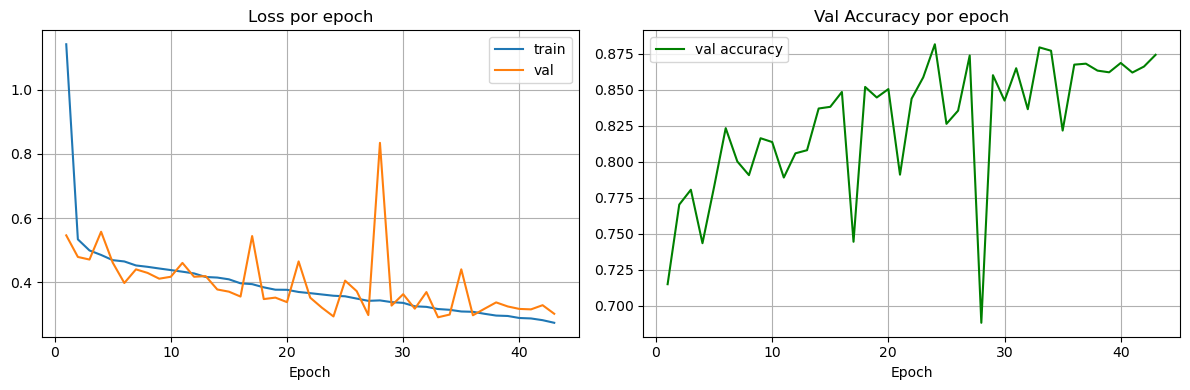

In [3]:
historial = train_cnn()